# Phase 3 — INDI Trajectory-tracking Control (walkthrough)

Phases 1-2 produced a feasible aerobatic *reference*. On its own that reference is
open-loop: the flatness transform carries two deliberate approximations (A1/A2), the
tailsitter is open-loop unstable, and any disturbance is uncorrected. Phase 3 adds
the **INDI tracking controller** from Doc 3 (Tal & Karaman, Sec. IV) and flies the
reference closed-loop in the 6-DOF plant.

The controller is a cascade of PD kinematics and INDI dynamics:

| stage | law | output |
|---|---|---|
| position / velocity | PD (Eq. 37) | acceleration command `a_c` |
| linear acceleration | INDI (Eq. 42) | attitude `xi_c`, thrust `T_c` |
| attitude / rate | PD (Eqs. 43-45) | angular-acceleration command |
| angular acceleration | INDI (Eq. 48) | moment `m_c` -> actuators |

Each INDI stage compares a **measured** acceleration with the **model** prediction at
the last applied input and commands the increment that cancels the difference — which
is exactly the unmodelled force/moment. So INDI absorbs A1/A2, parameter error, and
disturbances with no integral action, inverting *through* the Phase-1 flatness map.

## 0. Setup and a reference to track

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from dataclasses import replace
from tailsitter.config import load_config
from tailsitter.trajgen import min_snap_trajectory, allocate_times, maneuvers
from tailsitter.control import TailsitterINDI, fly, build_reference
from tailsitter.dynamics.sim6dof import Tailsitter6DOF
from tailsitter.utils.rotation import quat_to_euler_zxy

cfg = load_config()
m = maneuvers.loop(radius=3.0, entry_alt=3.0, n=16, speed=6.0)
sc = 2.2                                   # fly a bit slower than time-optimal -> margin
k = allocate_times(m["waypoints"], m["nominal_speed"]) * sc
tp, ty = min_snap_trajectory(m["waypoints"], k, yaw=m["yaw"], v0=m["v0"]/sc, v1=m["v1"]/sc)
ref = build_reference(tp, ty, cfg)
print(f"reference: vertical loop, duration {ref['ts'][-1]:.2f}s at {cfg.sim.dt*1e3:.1f} ms steps")
print("gains:", {k_: getattr(cfg.ctrl, k_) for k_ in ('Kx','Kv','Ka','Kq','Komega')})

reference: vertical loop, duration 6.87s at 0.5 ms steps
gains: {'Kx': 42.0, 'Kv': 13.0, 'Ka': 1.0, 'Kq': 240.0, 'Komega': 30.0}


## 1. Fly it closed-loop

Start exactly on the reference and integrate the plant at the 2 kHz sim rate, calling
the INDI controller every step. The vehicle tracks the aggressive loop — pitching
through inverted — to a few centimetres.

position RMSE = 7.91 cm   max = 10.89 cm


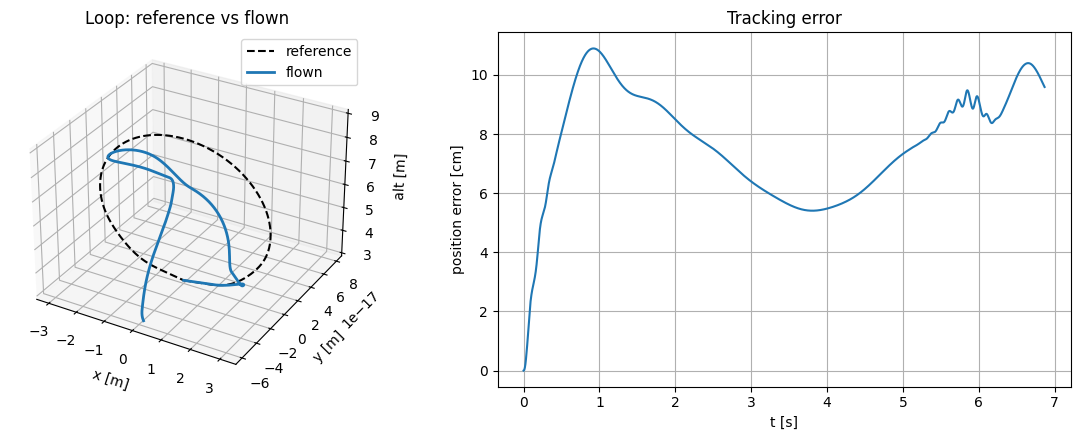

In [2]:
log = fly(cfg, TailsitterINDI(cfg), tp, ty, ref=ref)
print(f"position RMSE = {log['rmse']*100:.2f} cm   max = {log['max_err']*100:.2f} cm")

X, ts = log['X'], log['ts']
fig = plt.figure(figsize=(12, 4.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(ref['pos'][:,0], ref['pos'][:,1], -ref['pos'][:,2], 'k--', lw=1.5, label='reference')
ax.plot(X[:,0], X[:,1], -X[:,2], lw=2, label='flown')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('alt [m]')
ax.set_title('Loop: reference vs flown'); ax.legend()
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(ts, log['pos_err']*100); ax2.set_xlabel('t [s]')
ax2.set_ylabel('position error [cm]'); ax2.set_title('Tracking error'); ax2.grid()
plt.tight_layout(); plt.savefig('plots/p3_tracking.png', dpi=110); plt.show()

## 2. What the controller is doing

The flown attitude and body rate follow the flatness feedforward, and the actuator
commands stay within limits. The flaps work hardest during the pitch-down on the back
of the loop — the same place the reference saturates them in Phase 2.

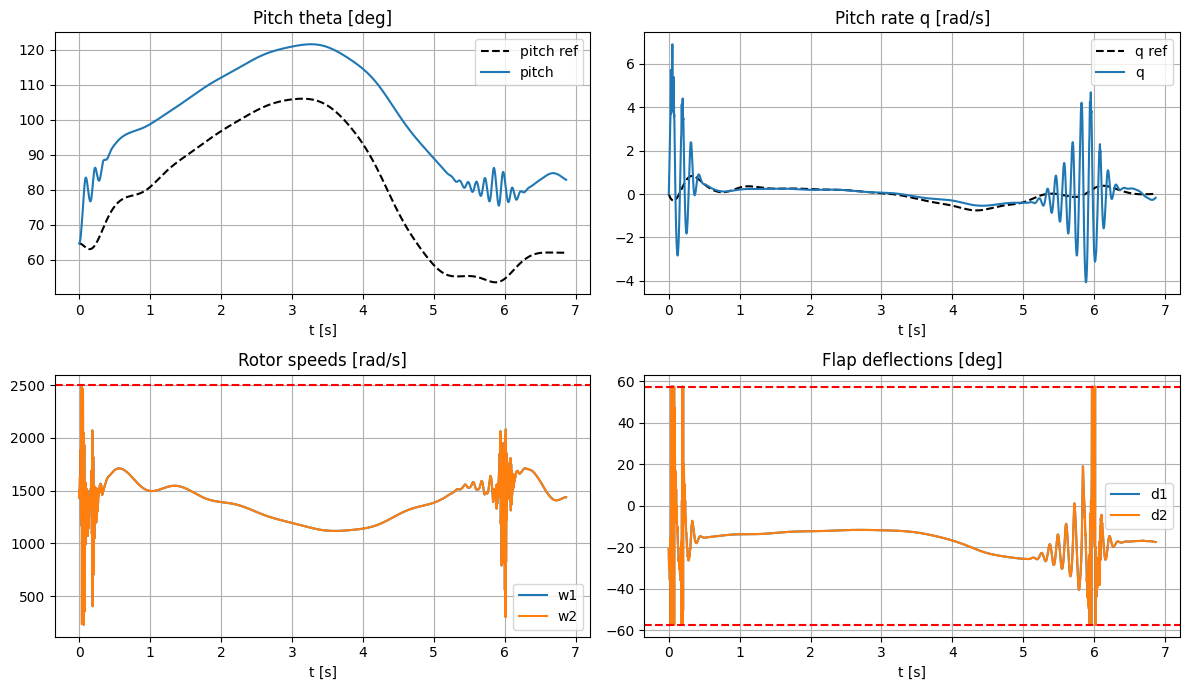

In [3]:
eul = np.array([quat_to_euler_zxy(q) for q in X[:,6:10]])
eul_ref = np.array([quat_to_euler_zxy(q) for q in ref['q']])
U = log['U']
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(ts, np.degrees(eul_ref[:,2]), 'k--', label='pitch ref')
ax[0,0].plot(ts, np.degrees(eul[:,2]), label='pitch')
ax[0,0].set_title('Pitch theta [deg]'); ax[0,0].legend(); ax[0,0].grid()
ax[0,1].plot(ts, ref['Omega'][:,1], 'k--', label='q ref'); ax[0,1].plot(ts, X[:,11], label='q')
ax[0,1].set_title('Pitch rate q [rad/s]'); ax[0,1].legend(); ax[0,1].grid()
ax[1,0].plot(ts, U[:,0], label='w1'); ax[1,0].plot(ts, U[:,1], label='w2')
ax[1,0].axhline(cfg.vehicle.w_max, ls='--', c='r'); ax[1,0].set_title('Rotor speeds [rad/s]')
ax[1,0].legend(); ax[1,0].grid()
ax[1,1].plot(ts, np.degrees(U[:,2]), label='d1'); ax[1,1].plot(ts, np.degrees(U[:,3]), label='d2')
ax[1,1].axhline(np.degrees(cfg.vehicle.flap_max), ls='--', c='r')
ax[1,1].axhline(np.degrees(cfg.vehicle.flap_min), ls='--', c='r')
ax[1,1].set_title('Flap deflections [deg]'); ax[1,1].legend(); ax[1,1].grid()
for a in ax.ravel(): a.set_xlabel('t [s]')
plt.tight_layout(); plt.savefig('plots/p3_inputs.png', dpi=110); plt.show()

## 3. Why INDI: robustness without retuning

The point of INDI is that it only needs *local* model accuracy. We give the
controller a deliberately **wrong** vehicle model (heavier, higher inertia, wrong
moment arms) and separately hit the plant with a **steady wind**. INDI keeps tracking
in both cases — and for contrast, applying the reference inputs **open-loop** (no
feedback) diverges completely.

  matched model                RMSE =     7.91 cm
  +25% mass / +40% inertia     RMSE =    17.47 cm
  2.2 N steady wind            RMSE =    27.50 cm
  open-loop (no feedback)      RMSE =  1383.73 cm


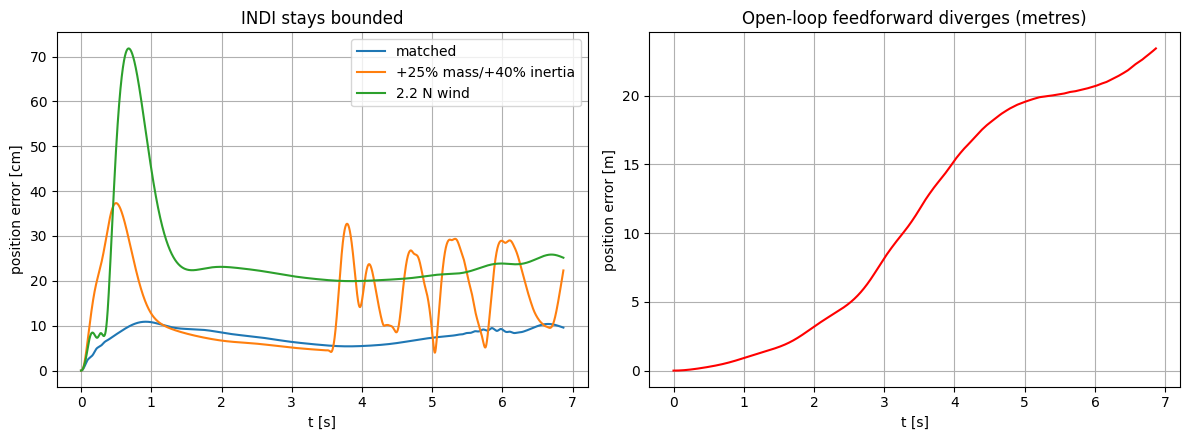

In [4]:
# mismatched controller model
vb = cfg.vehicle
mm = replace(cfg, vehicle=replace(vb, mass=vb.mass*1.25, inertia=vb.inertia*1.40,
                                  lTy=vb.lTy*1.2, lDx=vb.lDx*0.8, lDy=vb.lDy*1.2))
log_mm = fly(cfg, TailsitterINDI(cfg, model_cfg=mm), tp, ty, ref=ref)
# steady wind disturbance
Fw = np.array([2.0, 1.0, 0.0])
log_w = fly(cfg, TailsitterINDI(cfg), tp, ty, ref=ref, f_ext=lambda t: Fw)
# open-loop feedforward
plant = Tailsitter6DOF(cfg); x = np.concatenate([ref['pos'][0], ref['vel'][0], ref['q'][0], ref['Omega'][0]])
ol_err = []
for kk in range(len(ts)):
    u = np.array([ref['w1'][kk], ref['w2'][kk], ref['d1'][kk], ref['d2'][kk]])
    ol_err.append(np.linalg.norm(x[0:3]-ref['pos'][kk]))
    if kk < len(ts)-1: x = plant.step(x, u, cfg.sim.dt)
ol_err = np.array(ol_err)

for name, L in [("matched model", log['rmse']), ("+25% mass / +40% inertia", log_mm['rmse']),
                ("2.2 N steady wind", log_w['rmse']),
                ("open-loop (no feedback)", np.sqrt(np.mean(ol_err**2)))]:
    print(f"  {name:28s} RMSE = {L*100:8.2f} cm")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(ts, log['pos_err']*100, label='matched')
ax[0].plot(ts, log_mm['pos_err']*100, label='+25% mass/+40% inertia')
ax[0].plot(ts, log_w['pos_err']*100, label='2.2 N wind')
ax[0].set_ylabel('position error [cm]'); ax[0].set_title('INDI stays bounded'); ax[0].legend(); ax[0].grid()
ax[1].plot(ts, ol_err, 'r'); ax[1].set_ylabel('position error [m]')
ax[1].set_title('Open-loop feedforward diverges (metres)'); ax[1].grid()
for a in ax: a.set_xlabel('t [s]')
plt.tight_layout(); plt.savefig('plots/p3_robustness.png', dpi=110); plt.show()

## 4. Track the whole catalog

Fly each aerobatic figure (slowed slightly from its time-optimal timing for margin)
and report the closed-loop tracking error. The tighter, faster figures are harder,
but all stay within a modest error band.

> `line` and `knife_edge` have no curvature and (indoor, drag-free) no speed limit, so their time-optimal timing collapses; they are floored to the nominal speed here. `split_s` — an inverted, descending half-loop with a rapid direction reversal — is the hardest figure and shows the largest transient.

In [5]:
from tailsitter.trajgen import time_optimal_scale
MARGIN = 1.5   # fly at 1.5x each figure's own time-optimal timing (comfortable margin)
rows = []
for name, gen in maneuvers.CATALOG.items():
    mm2 = gen()
    k0 = allocate_times(mm2["waypoints"], mm2["nominal_speed"])
    try:
        o = time_optimal_scale(mm2["waypoints"], k0, yaw=mm2["yaw"], cfg=cfg,
                               v0=mm2["v0"], v1=mm2["v1"], N=250)
        a = max(o["alpha"] * MARGIN, 1.0)   # never faster than nominal (straight lines have no limit)
        kk = k0 * a
        tpi, tyi = min_snap_trajectory(mm2["waypoints"], kk, yaw=mm2["yaw"],
                                       v0=mm2["v0"]/a, v1=mm2["v1"]/a)
        L = fly(cfg, TailsitterINDI(cfg), tpi, tyi)
        rows.append((name, f"{L['ts'][-1]:.2f}", f"{L['rmse']*100:.2f}", f"{L['max_err']*100:.2f}"))
    except Exception as e:
        rows.append((name, 'n/a', str(e)[:24], '-'))
print(f"{'maneuver':26s}{'dur[s]':>8s}{'RMSE[cm]':>10s}{'max[cm]':>10s}")
print('-'*54)
for r in rows: print(f"{r[0]:26s}{r[1]:>8s}{r[2]:>10s}{r[3]:>10s}")

maneuver                    dur[s]  RMSE[cm]   max[cm]
------------------------------------------------------
line                          1.67      7.59      8.71
loop                          7.80      8.00     10.47
knife_edge                    1.67      4.59      5.39
climbing_turn                 6.92      8.70     10.41
immelmann                     2.58      8.23     12.30
split_s                       4.95     15.40     43.49
differential_thrust_turn      4.19      7.89      8.34
racing_gates                  8.11      7.86     10.37


## Summary — the full pipeline is closed

Phase 1 built the dynamics and the differential-flatness transform; Phase 2 generated
feasible, time-optimal aerobatic references; Phase 3 flies them closed-loop with an
INDI controller that tracks to centimetres and shrugs off model error and wind that
would make the open-loop reference diverge by metres.

The two flatness approximations from Phase 1 (A1: neglected non-minimum-phase flap
force; A2: neglected flap yaw moment) are exactly the kind of local model error the
INDI increments cancel — they never needed to be exact for closed-loop flight.

Everything remains driven by `config/tailsitter.yaml`; swap in measured vehicle
parameters and re-tune the five gains there for hardware.